In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

apple = pd.read_csv("../data/processed/APPLE_cleaned.csv")

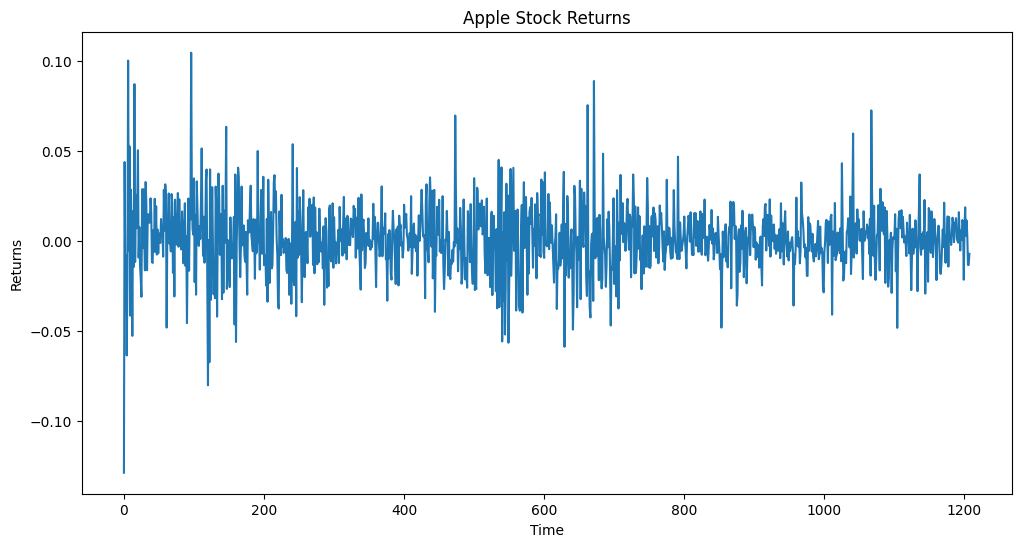

In [5]:
series = apple['Return']
plt.figure(figsize=(12,6))
plt.plot(series)
plt.title('Apple Stock Returns')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.show()

In [6]:
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(key, value)

ADF Statistic: -37.152304726641155
p-value: 0.0
Critical Values:
1% -3.43577938005948
5% -2.863937543790164
10% -2.568046493171221


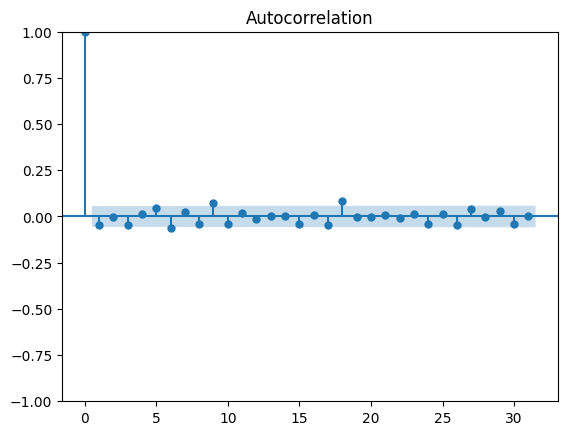

In [7]:
plot_acf(series)
plt.show()

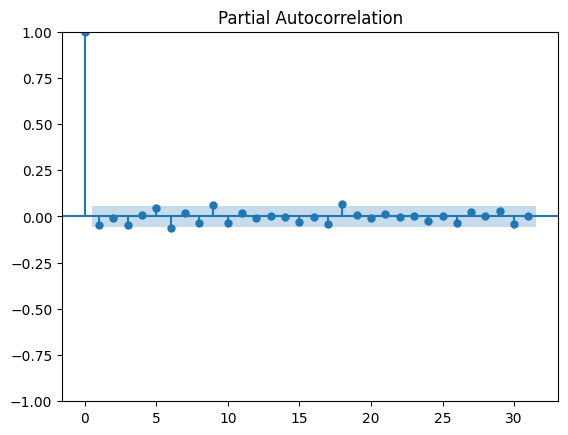

In [8]:
plot_pacf(series)
plt.show()

In [9]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

In [10]:
model = ARIMA(train, order=(0,0,1))

model_fit = model.fit()

In [11]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                  966
Model:                 ARIMA(0, 0, 1)   Log Likelihood                2413.105
Date:                Wed, 20 May 2026   AIC                          -4820.211
Time:                        17:19:25   BIC                          -4805.591
Sample:                             0   HQIC                         -4814.645
                                - 966                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.001      2.050      0.040    5.44e-05       0.002
ma.L1         -0.0653      0.028     -2.325      0.020      -0.120      -0.010
sigma2         0.0004   1.04e-05     38.058      0.0

In [12]:
predictions = model_fit.forecast(steps=len(test))

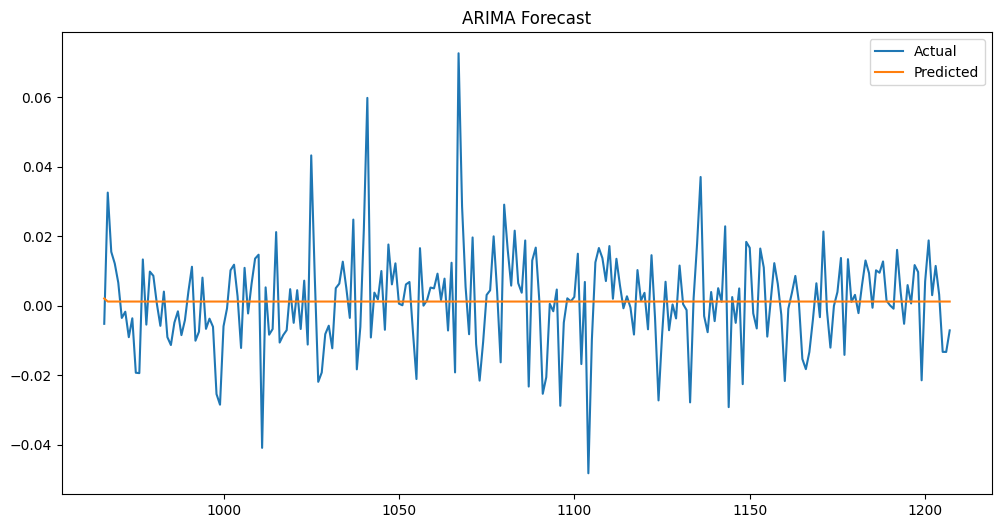

In [13]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, predictions, label='Predicted')

plt.title('ARIMA Forecast')

plt.legend()

plt.show()

In [14]:
mae = mean_absolute_error(test, predictions)

print('MAE:', mae)

MAE: 0.01030392640238137


In [15]:
rmse = np.sqrt(mean_squared_error(test, predictions))

print('RMSE:', rmse)

RMSE: 0.014203249150166608


In [16]:
models = [
    (0,0,0),
    (1,0,0),
    (0,0,1),
    (1,0,1),
    (2,0,1),
    (1,0,2),
]

for order in models:

    model = ARIMA(train, order=order)
    result = model.fit()

    print(f'ARIMA{order}')
    print('AIC:', result.aic)
    print('BIC:', result.bic)
    print('-------------------')

##ARIMA showed limited predictive capability on stock returns due to weak autocorrelation structure in financial time series. The returns series was stationary, but ACF/PACF analysis indicated minimal temporal dependence, resulting in only marginal improvements across ARIMA configurations.

ARIMA(0, 0, 0)
AIC: -4818.3104795905665
BIC: -4808.564151922142
-------------------
ARIMA(1, 0, 0)
AIC: -4820.174591601983
BIC: -4805.5551000993455
-------------------
ARIMA(0, 0, 1)
AIC: -4820.210861094523
BIC: -4805.591369591886
-------------------
ARIMA(1, 0, 1)
AIC: -4818.348689563187
BIC: -4798.856034226336
-------------------


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 0, 1)
AIC: -4816.199311177408
BIC: -4791.833492006345
-------------------
ARIMA(1, 0, 2)
AIC: -4816.499598373031
BIC: -4792.1337792019685
-------------------


In [17]:
results = pd.DataFrame({
    'Actual': test.values,
    'Predicted': predictions.values
})

results.to_csv(
    '../outputs/predictions/arima_baseline.csv',
    index=False
)

In [18]:
metrics = pd.DataFrame({
    'Model': ['ARIMA(0,0,1)'],
    'MAE': [mae],
    'RMSE': [rmse],
    'AIC': [model_fit.aic],
    'BIC': [model_fit.bic]
})
metrics.to_csv(
    '../outputs/metrics/arima_metrics.csv',
    index=False
)

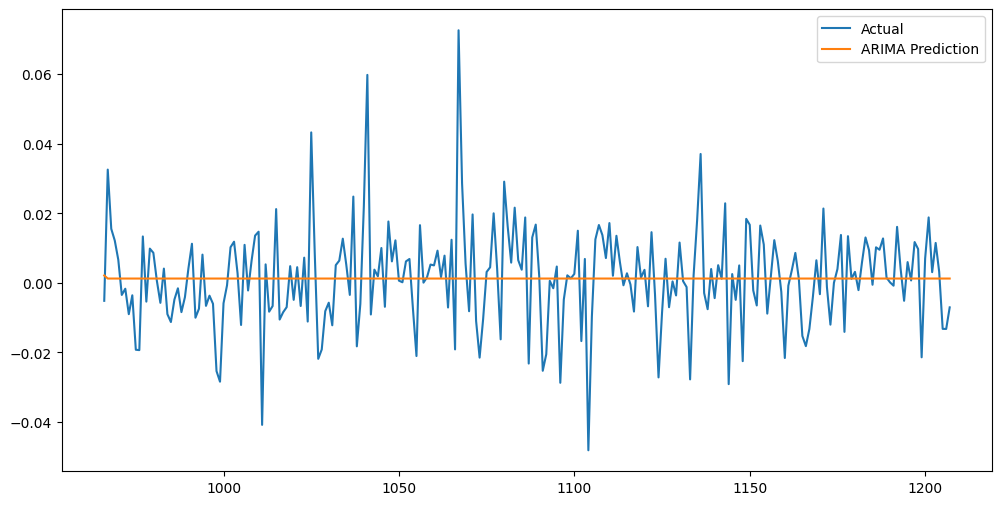

In [19]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, predictions, label='ARIMA Prediction')

plt.legend()

plt.savefig('../outputs/plots/arima_forecast.png')

plt.show()